In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup
import io
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score




# Project 2: Predicting Future Premier League Goal Difference

## Research Question

Can transfer spending and previous-season team performance predict a club's goal difference in the following Premier League season?

This project uses machine learning regression models to predict a club's goal difference in a future Premier League season based on transfer spending and performance from the previous season.

## Prediction Target and Features

**Target variable:**
- Future-Season Goal Difference

**Predictor variables:**
- Transfer Expenditure
- Previous-Season League Points
- Previous-Season Goal Difference
- Previous-Season Goals Scored
- Previous-Season Goals Conceded

Each observation represents one Premier League club paired with its following season. For example, a club's 2022-23 performance and transfer spending would be used to predict its 2023-24 goal difference.

In [2]:
seasons = {
    '2019-20': '1920',
    '2020-21': '2021',
    '2021-22': '2122',
    '2022-23': '2223',
    '2023-24': '2324',
    '2024-25': '2425'
}

## Data Collection

The data for this project comes from two sources. Premier League match results are collected from football-data.co.uk to calculate team performance statistics such as league points, goals scored, goals conceded, and goal difference. Transfer expenditure data is collected separately from Transfermarkt. The data covers the 2019–20 through 2024–25 Premier League seasons.


In [3]:
all_results = []

for season, season_code in seasons.items():
    url = f"https://www.football-data.co.uk/mmz4281/{season_code}/E0.csv"
    
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    
    data = pd.read_csv(io.StringIO(response.text))
    
    data = data[['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR']]
    data['Season'] = season
    
    all_results.append(data)

all_results = pd.concat(all_results, ignore_index=True)

print("Total matches:", len(all_results))
print(all_results['Season'].value_counts().sort_index())

Total matches: 2280
Season
2019-20    380
2020-21    380
2021-22    380
2022-23    380
2023-24    380
2024-25    380
Name: count, dtype: int64


## Calculating Team Performance

The match results are used to calculate each club's performance for every season. For each team, the code calculates total league points, goals scored, goals conceded, and goal difference. These statistics provide the previous-season performance variables used later in the prediction models.


In [4]:
team_stats_all = []

for season in seasons:
    season_data = all_results[all_results['Season'] == season]
    
    teams = pd.concat([
        season_data['HomeTeam'],
        season_data['AwayTeam']
    ]).unique()
    
    for team in teams:
        home_games = season_data[season_data['HomeTeam'] == team]
        away_games = season_data[season_data['AwayTeam'] == team]
        
        home_points = (
            (home_games['FTR'] == 'H').sum() * 3
            + (home_games['FTR'] == 'D').sum()
        )
        
        away_points = (
            (away_games['FTR'] == 'A').sum() * 3
            + (away_games['FTR'] == 'D').sum()
        )
        
        goals_scored = (
            home_games['FTHG'].sum()
            + away_games['FTAG'].sum()
        )
        
        goals_conceded = (
            home_games['FTAG'].sum()
            + away_games['FTHG'].sum()
        )
        
        team_stats_all.append({
            'Season': season,
            'Club': team,
            'League_Points': home_points + away_points,
            'Goals_Scored': goals_scored,
            'Goals_Conceded': goals_conceded
        })

team_stats_all = pd.DataFrame(team_stats_all)

team_stats_all['Goal_Difference'] = (
    team_stats_all['Goals_Scored']
    - team_stats_all['Goals_Conceded']
)

In [5]:
team_stats_all.head()

,Season,Club,League_Points,Goals_Scored,Goals_Conceded,Goal_Difference
0,2019-20,Liverpool,99,85,33,52
1,2019-20,West Ham,39,49,62,-13
2,2019-20,Bournemouth,34,40,65,-25
3,2019-20,Burnley,54,43,50,-7
4,2019-20,Crystal Palace,43,31,50,-19


## Preparing Performance and Transfer Data

The team statistics are organized by season to determine each club's final league position. Transfer expenditure is then collected from Transfermarkt for each Premier League season from 2019–20 through 2024–25. The transfer data is cleaned and converted to numeric values so it can be combined with the team performance data for the prediction analysis.


In [6]:
team_stats_all = team_stats_all.sort_values(
    ['Season', 'League_Points', 'Goal_Difference'],
    ascending=[True, False, False]
)

team_stats_all['Final_Position'] = (
    team_stats_all.groupby('Season').cumcount() + 1
)

In [7]:
def scrape_transfer_expenditure(season, season_id):
    url = (
        f"https://www.transfermarkt.com/premier-league/"
        f"einnahmenausgaben/wettbewerb/GB1/ids/a/sa//"
        f"saison_id/{season_id}/saison_id_bis/{season_id}/"
        f"nat/0/pos//w_s/intern/0/plus/1"
    )
    
    response = requests.get(
        url,
        headers={'User-Agent': 'Mozilla/5.0'},
        timeout=30
    )
    
    response.raise_for_status()
    
    soup = BeautifulSoup(response.text, 'html.parser')
    tables = soup.find_all('table')
    
    transfer_rows = tables[1].find_all('tr')
    
    transfer_data = []
    
    for row in transfer_rows[1:]:
        cells = row.find_all('td')
        
        if len(cells) >= 8:
            club = cells[2].get_text(" ", strip=True)
            expenditure = cells[3].get_text(" ", strip=True)
            
            transfer_data.append({
                'Season': season,
                'Club': club,
                'Transfer_Expenditure': expenditure
            })
    
    transfer_data = pd.DataFrame(transfer_data)
    
    transfer_data['Transfer_Expenditure'] = (
        transfer_data['Transfer_Expenditure']
        .str.replace('€', '', regex=False)
        .str.replace('m', '', regex=False)
        .astype(float)
    )
    
    return transfer_data

In [8]:
transfer_seasons = {
    '2019-20': 2019,
    '2020-21': 2020,
    '2021-22': 2021,
    '2022-23': 2022,
    '2023-24': 2023,
    '2024-25': 2024
}

all_transfers = []

for season, season_id in transfer_seasons.items():
    data = scrape_transfer_expenditure(season, season_id)
    all_transfers.append(data)

all_transfers = pd.concat(all_transfers, ignore_index=True)

print("Total club-season records:", len(all_transfers))
print(all_transfers['Season'].value_counts().sort_index())

Total club-season records: 120
Season
2019-20    20
2020-21    20
2021-22    20
2022-23    20
2023-24    20
2024-25    20
Name: count, dtype: int64


### Combining the Datasets

The club names from the two data sources are standardized so that the same teams can be matched correctly. The team performance and transfer expenditure data are then merged by season and club. The resulting dataset is checked for the total number of observations and any missing values before continuing with the analysis.


In [9]:
club_name_map = {
    'Liverpool FC': 'Liverpool',
    'Arsenal FC': 'Arsenal',
    'Manchester City': 'Man City',
    'Chelsea FC': 'Chelsea',
    'Newcastle United': 'Newcastle',
    'Aston Villa': 'Aston Villa',
    'Nottingham Forest': "Nott'm Forest",
    'Brighton & Hove Albion': 'Brighton',
    'AFC Bournemouth': 'Bournemouth',
    'Brentford FC': 'Brentford',
    'Fulham FC': 'Fulham',
    'Crystal Palace': 'Crystal Palace',
    'Everton FC': 'Everton',
    'West Ham United': 'West Ham',
    'Manchester United': 'Man United',
    'Wolverhampton Wanderers': 'Wolves',
    'Tottenham Hotspur': 'Tottenham',
    'Leicester City': 'Leicester',
    'Ipswich Town': 'Ipswich',
    'Southampton FC': 'Southampton',
    'Sheffield United': 'Sheffield United',
    'Burnley FC': 'Burnley',
    'Watford FC': 'Watford',
    'Norwich City': 'Norwich'
}

all_transfers['Club'] = all_transfers['Club'].replace(club_name_map)

all_transfers['Club'] = all_transfers['Club'].replace({
    'Leeds United': 'Leeds',
    'Luton Town': 'Luton',
    'West Bromwich Albion': 'West Brom'
})

In [10]:
analysis_data_all = pd.merge(
    team_stats_all,
    all_transfers,
    on=['Season', 'Club'],
    how='inner'
)

In [11]:
print("Total club-season records:", len(analysis_data_all))

print("\nMissing values:")
print(analysis_data_all.isna().sum())

print("\nRecords by season:")
print(analysis_data_all['Season'].value_counts().sort_index())

Total club-season records: 120

Missing values:
Season                  0
Club                    0
League_Points           0
Goals_Scored            0
Goals_Conceded          0
Goal_Difference         0
Final_Position          0
Transfer_Expenditure    0
dtype: int64

Records by season:
Season
2019-20    20
2020-21    20
2021-22    20
2022-23    20
2023-24    20
2024-25    20
Name: count, dtype: int64


## Creating Prediction Variables

To predict future performance, the data is separated into previous-season predictors and the following season's target variable. Previous-season transfer expenditure and team performance statistics are renamed to clearly identify them as predictors, while the following season's goal difference is used as the prediction target. A season mapping is then created to connect each previous season with the correct target season.


In [12]:
previous_season = analysis_data_all[
    [
        'Club',
        'Season',
        'Transfer_Expenditure',
        'League_Points',
        'Goal_Difference',
        'Goals_Scored',
        'Goals_Conceded'
    ]
].copy()

previous_season = previous_season.rename(columns={
    'Season': 'Previous_Season',
    'League_Points': 'Previous_League_Points',
    'Goal_Difference': 'Previous_Goal_Difference',
    'Goals_Scored': 'Previous_Goals_Scored',
    'Goals_Conceded': 'Previous_Goals_Conceded'
})

previous_season.head()

,Club,Previous_Season,Transfer_Expenditure,Previous_League_Points,Previous_Goal_Difference,Previous_Goals_Scored,Previous_Goals_Conceded
0,Liverpool,2019-20,10.40,99,52,85,33
1,Man City,2019-20,169.82,81,67,102,35
2,Man United,2019-20,236.80,66,30,66,36
3,Chelsea,2019-20,45.00,66,15,69,54
4,Leicester,2019-20,104.30,62,26,67,41


In [13]:
target_season = analysis_data_all[
    [
        'Club',
        'Season',
        'Goal_Difference'
    ]
].copy()

target_season = target_season.rename(columns={
    'Season': 'Target_Season',
    'Goal_Difference': 'Target_Goal_Difference'
})

target_season.head()

,Club,Target_Season,Target_Goal_Difference
0,Liverpool,2019-20,52
1,Man City,2019-20,67
2,Man United,2019-20,30
3,Chelsea,2019-20,15
4,Leicester,2019-20,26


In [14]:
next_season = {
    '2019-20': '2020-21',
    '2020-21': '2021-22',
    '2021-22': '2022-23',
    '2022-23': '2023-24',
    '2023-24': '2024-25'
}

previous_season['Target_Season'] = (
    previous_season['Previous_Season'].map(next_season)
)

previous_season.head()

,Club,Previous_Season,Transfer_Expenditure,Previous_League_Points,Previous_Goal_Difference,Previous_Goals_Scored,Previous_Goals_Conceded,Target_Season
0,Liverpool,2019-20,10.40,99,52,85,33,2020-21
1,Man City,2019-20,169.82,81,67,102,35,2020-21
2,Man United,2019-20,236.80,66,30,66,36,2020-21
3,Chelsea,2019-20,45.00,66,15,69,54,2020-21
4,Leicester,2019-20,104.30,62,26,67,41,2020-21


### Building the Prediction Dataset

The previous-season predictors are merged with the corresponding target-season goal difference for each club. The completed dataset is checked for the number of observations and missing values, then organized into the variables used for the analysis.


In [15]:
prediction_data = pd.merge(
    previous_season,
    target_season,
    on=['Club', 'Target_Season'],
    how='inner'
)

In [16]:
prediction_data.head(10)

,Club,Previous_Season,Transfer_Expenditure,Previous_League_Points,Previous_Goal_Difference,Previous_Goals_Scored,Previous_Goals_Conceded,Target_Season,Target_Goal_Difference
0,Liverpool,2019-20,10.40,99,52,85,33,2020-21,26
1,Man City,2019-20,169.82,81,67,102,35,2020-21,51
2,Man United,2019-20,236.80,66,30,66,36,2020-21,29
3,Chelsea,2019-20,45.00,66,15,69,54,2020-21,22
4,Leicester,2019-20,104.30,62,26,67,41,2020-21,18
5,Tottenham,2019-20,150.50,59,14,61,47,2020-21,23
6,Wolves,2019-20,116.70,59,11,51,40,2020-21,-16
7,Arsenal,2019-20,160.80,56,8,56,48,2020-21,16
8,Sheffield United,2019-20,72.50,54,0,39,39,2020-21,-43
9,Burnley,2019-20,23.85,54,-7,43,50,2020-21,-22


In [17]:
print("Number of prediction observations:", len(prediction_data))
print("\nMissing values:")
print(prediction_data.isna().sum())

Number of prediction observations: 85

Missing values:
Club                        0
Previous_Season             0
Transfer_Expenditure        0
Previous_League_Points      0
Previous_Goal_Difference    0
Previous_Goals_Scored       0
Previous_Goals_Conceded     0
Target_Season               0
Target_Goal_Difference      0
dtype: int64


In [18]:
prediction_data = prediction_data[
    [
        'Club',
        'Previous_Season',
        'Target_Season',
        'Transfer_Expenditure',
        'Previous_League_Points',
        'Previous_Goal_Difference',
        'Previous_Goals_Scored',
        'Previous_Goals_Conceded',
        'Target_Goal_Difference'
    ]
]

prediction_data.head(10)

,Club,Previous_Season,Target_Season,Transfer_Expenditure,Previous_League_Points,Previous_Goal_Difference,Previous_Goals_Scored,Previous_Goals_Conceded,Target_Goal_Difference
0,Liverpool,2019-20,2020-21,10.40,99,52,85,33,26
1,Man City,2019-20,2020-21,169.82,81,67,102,35,51
2,Man United,2019-20,2020-21,236.80,66,30,66,36,29
3,Chelsea,2019-20,2020-21,45.00,66,15,69,54,22
4,Leicester,2019-20,2020-21,104.30,62,26,67,41,18
5,Tottenham,2019-20,2020-21,150.50,59,14,61,47,23
6,Wolves,2019-20,2020-21,116.70,59,11,51,40,-16
7,Arsenal,2019-20,2020-21,160.80,56,8,56,48,16
8,Sheffield United,2019-20,2020-21,72.50,54,0,39,39,-43
9,Burnley,2019-20,2020-21,23.85,54,-7,43,50,-22


In [19]:
prediction_data.describe()

,Transfer_Expenditure,Previous_League_Points,Previous_Goal_Difference,Previous_Goals_Scored,Previous_Goals_Conceded,Target_Goal_Difference
count,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000
mean,121.272824,57.247059,6.564706,57.894118,51.329412,6.176471
std,91.719648,15.553216,25.832080,17.528904,11.764948,25.246959
min,1.100000,35.000000,-37.000000,31.000000,26.000000,-43.000000
25%,63.400000,45.000000,-13.000000,43.000000,43.000000,-13.000000
50%,101.350000,55.000000,2.000000,55.000000,51.000000,3.000000
75%,156.300000,66.000000,19.000000,68.000000,61.000000,21.000000
max,630.250000,99.000000,73.000000,102.000000,79.000000,73.000000


## Correlation and Multicollinearity Analysis

Correlation analysis is used to examine the relationships between the predictors and the target variable. A correlation heatmap provides a visual summary of these relationships. Variance Inflation Factor (VIF) is also calculated to identify multicollinearity among the predictor variables, which can affect the interpretation of regression coefficients.


In [20]:
correlation_matrix = prediction_data[
    [
        'Transfer_Expenditure',
        'Previous_League_Points',
        'Previous_Goal_Difference',
        'Previous_Goals_Scored',
        'Previous_Goals_Conceded',
        'Target_Goal_Difference'
    ]
].corr()

correlation_matrix

,Transfer_Expenditure,Previous_League_Points,Previous_Goal_Difference,Previous_Goals_Scored,Previous_Goals_Conceded,Target_Goal_Difference
Transfer_Expenditure,1.000000,0.224518,0.234365,0.259359,-0.128164,0.348349
Previous_League_Points,0.224518,1.000000,0.952807,0.894163,-0.759824,0.650407
Previous_Goal_Difference,0.234365,0.952807,1.000000,0.923288,-0.820050,0.692703
Previous_Goals_Scored,0.259359,0.894163,0.923288,1.000000,-0.537321,0.677768
Previous_Goals_Conceded,-0.128164,-0.759824,-0.820050,-0.537321,1.000000,-0.511131
Target_Goal_Difference,0.348349,0.650407,0.692703,0.677768,-0.511131,1.000000


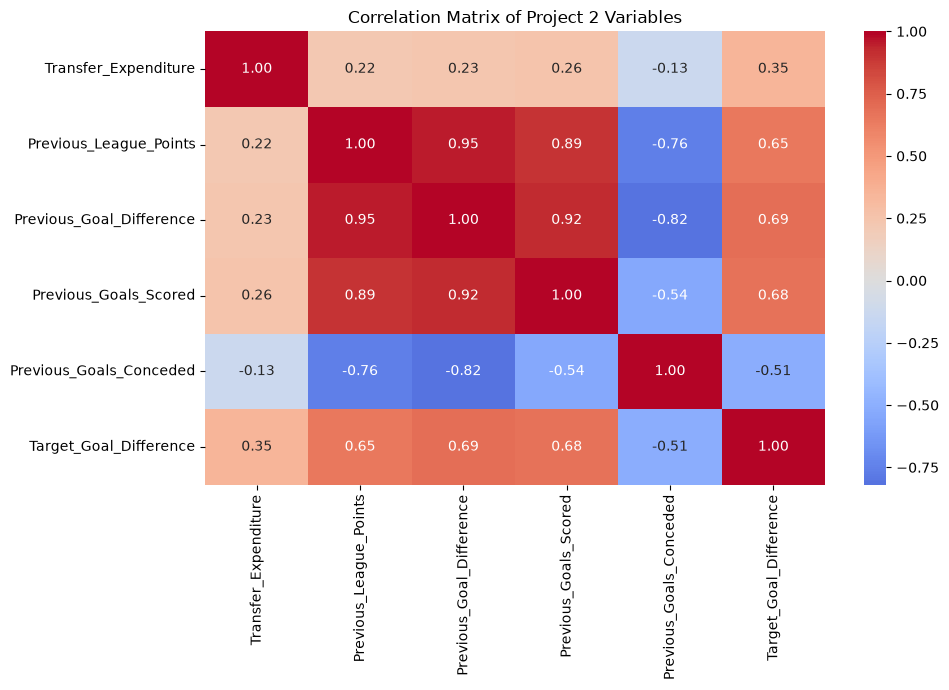

In [21]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title('Correlation Matrix of Project 2 Variables')
plt.tight_layout()
plt.show()

In [45]:
X_vif = prediction_data[
    [
        'Transfer_Expenditure',
        'Previous_League_Points',
        'Previous_Goal_Difference',
        'Previous_Goals_Scored',
        'Previous_Goals_Conceded'
    ]
]

vif_data = pd.DataFrame()

vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data

/var/folders/kk/ssmvv61j3rvd4trrm7n2qf1m0000gn/T/ipykernel_12481/1580681100.py:15: UserWarning: The design matrix is poorly conditioned (condition number=7.42e+15). VIF calculations may be numerically unstable.
  variance_inflation_factor(X_vif.values, i)
/Users/mazu_rx8/Documents/ds-studio-ii/.venv/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/Users/mazu_rx8/Documents/ds-studio-ii/.venv/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


,Feature,VIF
0,Transfer_Expenditure,1.072435e+00
1,Previous_League_Points,1.102123e+01
2,Previous_Goal_Difference,1.000800e+15
3,Previous_Goals_Scored,1.000800e+15
4,Previous_Goals_Conceded,1.000800e+15


## Preparing the Modeling Data

The variables selected for the prediction models are separated into a final modeling dataset. VIF is recalculated using the selected predictors to check the level of multicollinearity that remains. The data is then divided chronologically into training and testing sets, with the 2024–25 season reserved as the held-out test set.


In [46]:
model_data = prediction_data[
    [
        'Club',
        'Previous_Season',
        'Target_Season',
        'Transfer_Expenditure',
        'Previous_League_Points',
        'Previous_Goal_Difference',
        'Target_Goal_Difference'
    ]
].copy()

model_data.head()

,Club,Previous_Season,Target_Season,Transfer_Expenditure,Previous_League_Points,Previous_Goal_Difference,Target_Goal_Difference
0,Liverpool,2019-20,2020-21,10.40,99,52,26
1,Man City,2019-20,2020-21,169.82,81,67,51
2,Man United,2019-20,2020-21,236.80,66,30,29
3,Chelsea,2019-20,2020-21,45.00,66,15,22
4,Leicester,2019-20,2020-21,104.30,62,26,18


In [47]:
X_vif_reduced = model_data[
    [
        'Transfer_Expenditure',
        'Previous_League_Points',
        'Previous_Goal_Difference'
    ]
]

vif_data_reduced = pd.DataFrame()

vif_data_reduced['Feature'] = X_vif_reduced.columns
vif_data_reduced['VIF'] = [
    variance_inflation_factor(X_vif_reduced.values, i)
    for i in range(X_vif_reduced.shape[1])
]

vif_data_reduced

,Feature,VIF
0,Transfer_Expenditure,1.058137
1,Previous_League_Points,10.851079
2,Previous_Goal_Difference,10.902960


In [48]:
train_data = model_data[
    model_data['Target_Season'] < '2024-25'
].copy()

test_data = model_data[
    model_data['Target_Season'] == '2024-25'
].copy()

print("Training observations:", len(train_data))
print("Testing observations:", len(test_data))

Training observations: 68
Testing observations: 17


## Setting Up Model Features

The final three predictors are used to create the training and testing feature sets: transfer expenditure, previous-season league points, and previous-season goal difference. The target variable is the club's goal difference in the following season. The shapes of the resulting datasets are checked to confirm that the training and testing data are set up correctly.


In [49]:
features = [
    'Transfer_Expenditure',
    'Previous_League_Points',
    'Previous_Goal_Difference'
]

X_train = train_data[features]
y_train = train_data['Target_Goal_Difference']

X_test = test_data[features]
y_test = test_data['Target_Goal_Difference']

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (68, 3)
X_test: (17, 3)
y_train: (68,)
y_test: (17,)


## Baseline Model

A mean baseline is used as a simple benchmark for evaluating the regression models. The baseline predicts the same value for every test observation using the average target value from the training data. MAE, RMSE, and R² are calculated so the later models can be compared against this benchmark.


In [50]:
baseline_prediction = y_train.mean()

print("Baseline prediction:", baseline_prediction)

Baseline prediction: 5.470588235294118


In [51]:
baseline_predictions = np.full(
    len(y_test),
    baseline_prediction
)

print(baseline_predictions)

[5.47058824 5.47058824 5.47058824 5.47058824 5.47058824 5.47058824
 5.47058824 5.47058824 5.47058824 5.47058824 5.47058824 5.47058824
 5.47058824 5.47058824 5.47058824 5.47058824 5.47058824]


In [ ]:
baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print("Baseline MAE:", round(baseline_mae, 3))
print("Baseline RMSE:", round(baseline_rmse, 3))
print("Baseline R²:", round(baseline_r2, 3))

Baseline MAE: 13.211
Baseline RMSE: 16.81
Baseline R²: -0.046


## Linear Regression Model

A Linear Regression model is trained using the three selected predictors to estimate future goal difference. Predictions are evaluated using MAE, RMSE, and R², and the model coefficients are examined to understand the direction and relative effect of each predictor on the predicted goal difference.


In [54]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.08,0.27,0.52]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Transfer_Expenditure','Previous_League_Points', 'Previous_Goal_Difference']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-21.66
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [55]:
linear_predictions = linear_model.predict(X_test)

print(linear_predictions)

[ 55.35352757  52.9176116   37.24648666  14.92057784  24.18845996
  37.31665702  18.60528847  10.41079368  -3.82581443  -3.77350719
  -4.1565831  -11.39398714  -5.51223525  -6.51206322  -9.87821956
 -10.29373855 -11.21632999]


In [56]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression MAE:", round(linear_mae, 3))
print("Linear Regression RMSE:", round(linear_rmse, 3))
print("Linear Regression R²:", round(linear_r2, 3))

Linear Regression MAE: 13.73
Linear Regression RMSE: 15.675
Linear Regression R²: 0.09


In [57]:
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': linear_model.coef_
})

coefficients

,Feature,Coefficient
0,Transfer_Expenditure,0.077514
1,Previous_League_Points,0.268416
2,Previous_Goal_Difference,0.523594


In [58]:
print("Intercept:", linear_model.intercept_)

Intercept: -21.65774009448372


### Random Forest Model

A Random Forest Regression model is trained using the same three predictors as the Linear Regression model. The model's predictions are evaluated using MAE, RMSE, and R² so its performance can be compared with the baseline and Linear Regression models. The prediction results are also organized with the actual and predicted goal differences for further error analysis.


In [60]:
random_forest = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

random_forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [61]:
rf_predictions = random_forest.predict(X_test)

print(rf_predictions)

[ 55.425  57.665  52.345  32.83   24.435  20.275  25.31    7.975  13.015
 -14.73    2.135  -4.05    2.84  -12.315  -3.455 -13.885   2.665]


In [62]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest MAE:", round(rf_mae, 3))
print("Random Forest RMSE:", round(rf_rmse, 3))
print("Random Forest R²:", round(rf_r2, 3))

Random Forest MAE: 14.565
Random Forest RMSE: 17.223
Random Forest R²: -0.098


In [63]:
prediction_results = test_data[
    ['Club', 'Target_Season', 'Target_Goal_Difference']
].copy()

prediction_results['Predicted_Goal_Difference'] = linear_predictions

prediction_results['Error'] = (
    prediction_results['Target_Goal_Difference']
    - prediction_results['Predicted_Goal_Difference']
)

prediction_results

,Club,Target_Season,Target_Goal_Difference,Predicted_Goal_Difference,Error
68,Man City,2024-25,28,55.353528,-27.353528
69,Arsenal,2024-25,35,52.917612,-17.917612
70,Liverpool,2024-25,45,37.246487,7.753513
71,Aston Villa,2024-25,7,14.920578,-7.920578
72,Tottenham,2024-25,-1,24.188460,-25.188460
73,Chelsea,2024-25,21,37.316657,-16.316657
74,Newcastle,2024-25,21,18.605288,2.394712
75,Man United,2024-25,-10,10.410794,-20.410794
76,West Ham,2024-25,-16,-3.825814,-12.174186
77,Crystal Palace,2024-25,0,-3.773507,3.773507


## Prediction Error Analysis

The prediction errors from the Linear Regression model are examined to identify which clubs had the largest differences between their actual and predicted goal difference. Absolute error is used to rank the largest prediction mistakes. Two visualizations are also used to evaluate model performance: an actual-versus-predicted plot shows how closely predictions follow the observed values, while a residual plot helps identify patterns or unusually large errors.


In [64]:
prediction_results['Absolute_Error'] = (
    prediction_results['Error'].abs()
)

prediction_results.sort_values(
    'Absolute_Error',
    ascending=False
)

,Club,Target_Season,Target_Goal_Difference,Predicted_Goal_Difference,Error,Absolute_Error
68,Man City,2024-25,28,55.353528,-27.353528,27.353528
72,Tottenham,2024-25,-1,24.188460,-25.188460,25.188460
84,Nott'm Forest,2024-25,12,-11.216330,23.216330,23.216330
75,Man United,2024-25,-10,10.410794,-20.410794,20.410794
83,Brentford,2024-25,9,-10.293739,19.293739,19.293739
69,Arsenal,2024-25,35,52.917612,-17.917612,17.917612
80,Bournemouth,2024-25,12,-5.512235,17.512235,17.512235
73,Chelsea,2024-25,21,37.316657,-16.316657,16.316657
76,West Ham,2024-25,-16,-3.825814,-12.174186,12.174186
78,Brighton,2024-25,7,-4.156583,11.156583,11.156583


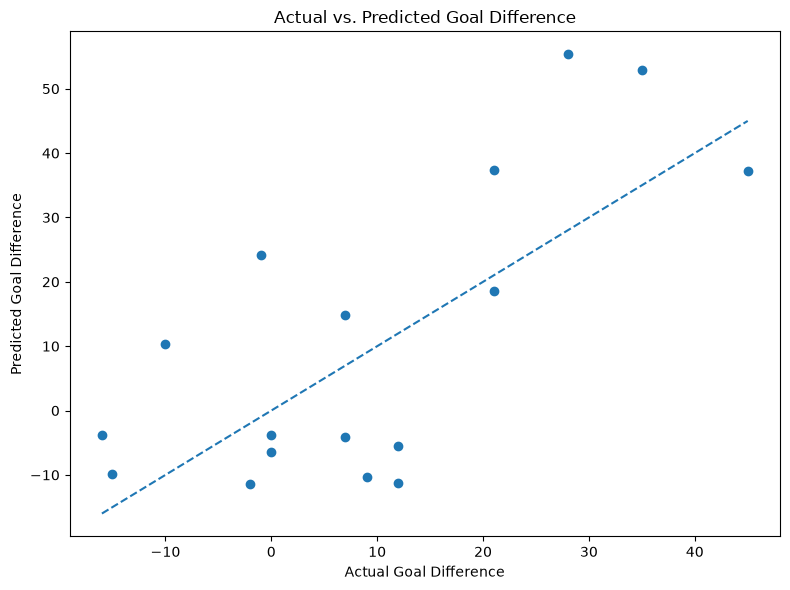

In [65]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    linear_predictions
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel('Actual Goal Difference')
plt.ylabel('Predicted Goal Difference')
plt.title('Actual vs. Predicted Goal Difference')

plt.tight_layout()
plt.show()

In [66]:
prediction_results['Residual'] = prediction_results['Error']

prediction_results[['Club', 'Target_Goal_Difference',
                    'Predicted_Goal_Difference', 'Residual']]

,Club,Target_Goal_Difference,Predicted_Goal_Difference,Residual
68,Man City,28,55.353528,-27.353528
69,Arsenal,35,52.917612,-17.917612
70,Liverpool,45,37.246487,7.753513
71,Aston Villa,7,14.920578,-7.920578
72,Tottenham,-1,24.188460,-25.188460
73,Chelsea,21,37.316657,-16.316657
74,Newcastle,21,18.605288,2.394712
75,Man United,-10,10.410794,-20.410794
76,West Ham,-16,-3.825814,-12.174186
77,Crystal Palace,0,-3.773507,3.773507


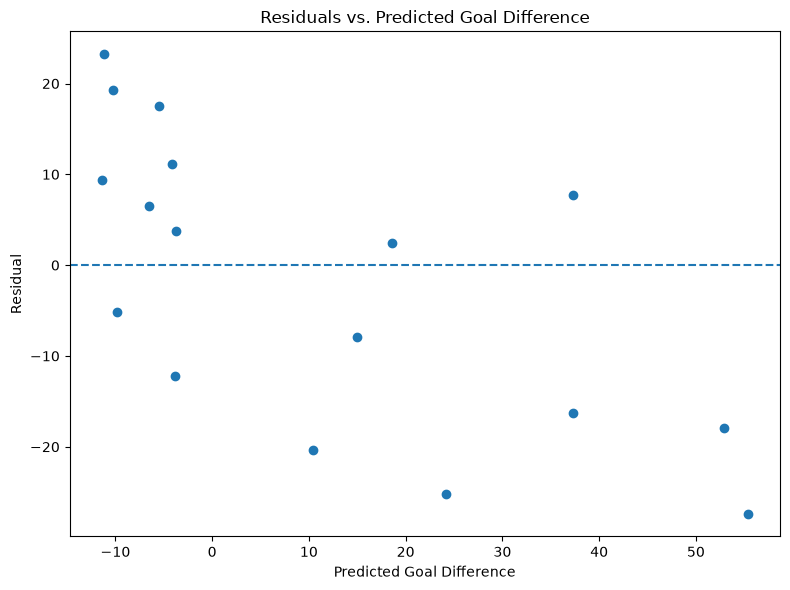

In [67]:
plt.figure(figsize=(8, 6))

plt.scatter(
    linear_predictions,
    prediction_results['Residual']
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Predicted Goal Difference')
plt.ylabel('Residual')
plt.title('Residuals vs. Predicted Goal Difference')

plt.tight_layout()
plt.show()

## Feature Importance and Model Comparison

The Random Forest feature importance scores are examined to determine which predictors contributed most to the model's predictions. The performance of the Mean Baseline, Linear Regression, and Random Forest models is then compared using MAE, RMSE, and R². A bar chart of RMSE provides a visual comparison of the models' prediction error.


In [68]:
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

feature_importance

,Feature,Importance
2,Previous_Goal_Difference,0.394468
1,Previous_League_Points,0.360912
0,Transfer_Expenditure,0.244619


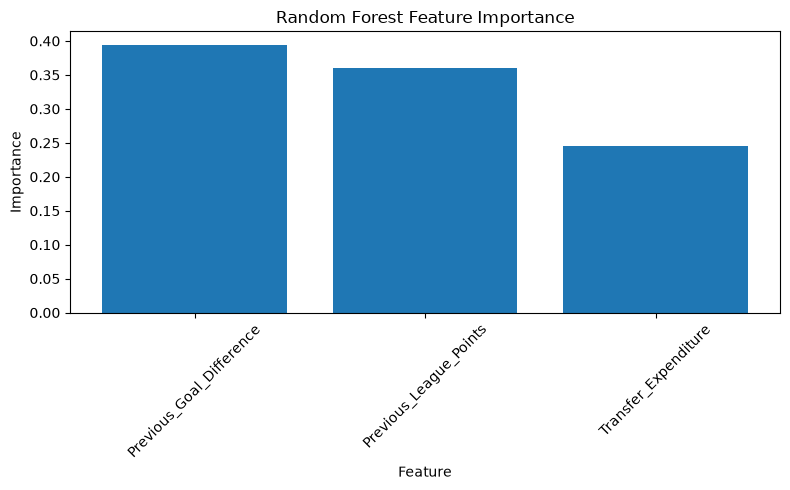

In [69]:
plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Random Forest Feature Importance')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [71]:
model_comparison = pd.DataFrame({
    'Model': [
        'Mean Baseline',
        'Linear Regression',
        'Random Forest'
    ],
    'MAE': [
        baseline_mae,
        linear_mae,
        rf_mae
    ],
    'RMSE': [
        baseline_rmse,
        linear_rmse,
        rf_rmse
    ],
    'R²': [
        baseline_r2,
        linear_r2,
        rf_r2
    ]
})

model_comparison

,Model,MAE,RMSE,R²
0,Mean Baseline,13.211073,16.809949,-0.046116
1,Linear Regression,13.730015,15.674758,0.090404
2,Random Forest,14.565294,17.222665,-0.098115


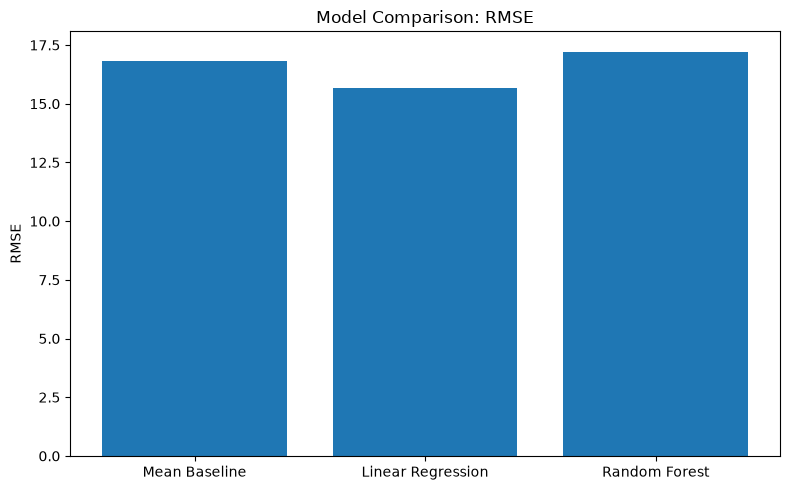

In [72]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison['Model'],
    model_comparison['RMSE']
)

plt.ylabel('RMSE')
plt.title('Model Comparison: RMSE')

plt.tight_layout()
plt.show()

## Final Findings and Conclusion

### Research Question

Can transfer spending and previous-season team performance predict a club's goal difference in the following Premier League season?

### Key Findings

- Transfer Expenditure had a positive correlation with future Goal Difference (r = 0.348), suggesting that higher spending was generally associated with better future performance.
- Previous Goal Difference had the strongest correlation with future Goal Difference (r = 0.693), followed by Previous League Points (r = 0.650).
- Both models placed previous-season performance variables ahead of Transfer Expenditure. The Random Forest ranked Previous Goal Difference as the most important feature (0.394), followed by Previous League Points (0.361) and Transfer Expenditure (0.245).
- Linear Regression performed best overall based on RMSE (15.675) and R² (0.090), although the Mean Baseline had a slightly lower MAE (13.211 compared with 13.730).

### Model Selection

Linear Regression was selected as the preferred model because it achieved the lowest RMSE (15.675) and the highest R² (0.090) on the held-out 2024–25 test set. Although the Mean Baseline achieved a slightly lower MAE (13.211 compared with 13.730), Linear Regression performed better at reducing larger prediction errors and explained more variation in future Goal Difference. Random Forest performed worse than both models across all three evaluation metrics.

### Limitations

- The test set contains only 17 clubs from the 2024–25 Premier League season, so the model's performance may not generalize to other seasons.
- The models only use Transfer Expenditure, Previous League Points, and Previous Goal Difference. Other factors such as injuries, managerial changes, squad changes, tactics, and fixture difficulty could also affect future performance.
- Previous League Points and Previous Goal Difference had high VIF values, indicating multicollinearity between these predictors. Therefore, their individual regression coefficients should be interpreted cautiously.
- The analysis identifies associations and predictive relationships rather than causal effects. A positive relationship between transfer spending and future Goal Difference does not mean that spending directly causes improved performance.

### Conclusion

Overall, transfer expenditure showed a positive but limited relationship with future Goal Difference. Previous-season performance was more strongly associated with future performance and was more influential in both models. Linear Regression was the preferred model based on RMSE and R², but its performance was still modest, indicating that the three predictors alone do not fully explain changes in club performance. These results suggest that transfer spending can provide some predictive information, but previous-season performance is more useful for predicting future Goal Difference within this dataset.